In [2]:
import os
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [4]:
# Define dataset path (update this to your actual path)
DATASET_PATH = r"C:\Users\Amber Gupta\Downloads\archive (6)\PlantVillage"

# Define image parameters
IMG_SIZE = 32  # Resize images to 64x64
NUM_CLASSES = 38

In [5]:
import cv2

In [6]:
def load_images(dataset_path):
    images = []
    labels = []
    class_names = sorted(os.listdir(dataset_path))  # Get class names (folder names)
    
    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            continue  # Skip non-directory files
        
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            img = cv2.imread(image_path)
            if img is None:
                continue  # Skip unreadable files
            
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize image
            img = img.astype("float32") / 255.0  # Normalize pixel values
            
            images.append(img)
            labels.append(class_idx)
    
    return np.array(images), np.array(labels), class_names

In [7]:
X, y, class_names = load_images(DATASET_PATH)

In [8]:
y = to_categorical(y, num_classes=NUM_CLASSES)

In [9]:
type(X)

numpy.ndarray

In [10]:
X.shape

(20638, 32, 32, 3)

In [11]:
X[0].shape

(32, 32, 3)

In [12]:
y.shape

(20638, 38)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
X_train, X_test = X_train / 255.0, X_test / 255.0

In [15]:
X_train = X_train.reshape(X_train.shape[0], -1)  # (num_samples, features)
X_test = X_test.reshape(X_test.shape[0], -1)

In [16]:
X_train.shape

(16510, 3072)

In [21]:
from tensorflow import keras

# Define the ANN model
model = keras.Sequential([
    keras.layers.Input(shape=(3072,)),  # Explicit Input Layer
    keras.layers.Dense(128, activation='relu'),  # Hidden layer 1
    keras.layers.Dense(64, activation='relu'),  # Hidden layer 2
    keras.layers.Dense(38, activation='softmax')  # Output layer (10 classes)
])

In [22]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │         393,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 38)                  │           2,470 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 404,070 (1.54 MB)

 Trainable params: 404,070 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1417 - loss: 2.8596 - val_accuracy: 0.1749 - val_loss: 2.5280
Epoch 2/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1985 - loss: 2.4526 - val_accuracy: 0.2677 - val_loss: 2.1658
Epoch 3/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3001 - loss: 2.1194 - val_accuracy: 0.3903 - val_loss: 1.8776
Epoch 4/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4121 - loss: 1.8519 - val_accuracy: 0.4598 - val_loss: 1.7302
Epoch 5/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4588 - loss: 1.7206 - val_accuracy: 0.4910 - val_loss: 1.6396
Epoch 6/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4771 - loss: 1.6492 - val_accuracy: 0.5208 - val_loss: 1.5707
Epoch 7/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5041 - loss: 1.5692 - val_accuracy: 0.5300 - val_loss: 1.5162
Epoch 8/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5312 - loss: 1.4931 - val_accuracy: 0.

In [25]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6519 - loss: 1.1122
Test Accuracy: 65.38%


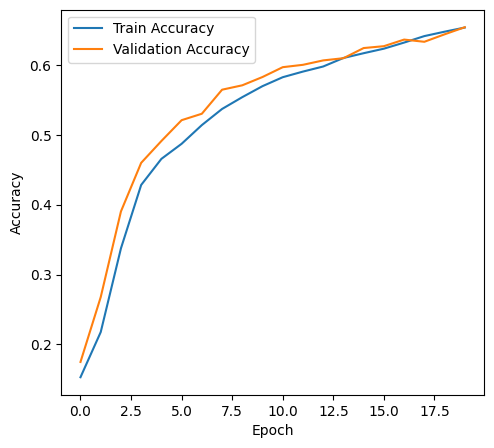

In [26]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

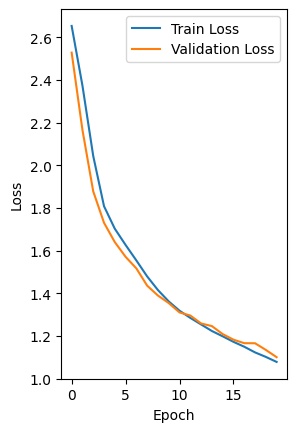

In [27]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()